# Kunal Ghanwat — Baseline Model & Naive Bayes
## CS6140: Machine Learning Final Project
### Customer Complaint Classification

**My Role:** Build and evaluate two models:
1. **Baseline Model** (Majority Class Classifier) — the minimum bar to beat
2. **Naive Bayes** (MultinomialNB) — a probability-based text classifier

**Dataset:** Preprocessed complaints from `complaints_cleaned.csv`
- Features: `Issue` and `Sub-issue` (text describing the complaint)
- Target: `Product` (18 financial product categories)
- Records: 1,282,355

---
## CELL 1: Import Libraries

**What this does:** Loads all the tools we need.
- `pandas` — for loading and working with our data table
- `numpy` — for math operations
- `sklearn` — our machine learning toolkit (models, metrics, TF-IDF)
- `matplotlib` and `seaborn` — for creating charts and plots

**Why:** Python doesn't have ML tools built-in. We import them from libraries that experts have already built and tested.

In [7]:
# ===== DATA HANDLING =====
# pandas: Think of it like Excel for Python — loads CSV files into tables
import pandas as pd

# numpy: Handles math operations on large arrays of numbers
import numpy as np

# ===== TEXT PROCESSING =====
# TfidfVectorizer: Converts text into numbers that ML models can understand
# TF-IDF = Term Frequency - Inverse Document Frequency
# It scores each word by how important it is to a specific complaint
from sklearn.feature_extraction.text import TfidfVectorizer

# ===== TRAIN-TEST SPLIT =====
# Splits data into training set (model learns) and test set (we quiz the model)
from sklearn.model_selection import train_test_split

# ===== MODELS =====
# DummyClassifier: Our baseline — always predicts the most common category
from sklearn.dummy import DummyClassifier

# MultinomialNB: Naive Bayes model designed for text classification
from sklearn.naive_bayes import MultinomialNB

# ===== EVALUATION METRICS =====
# These tell us how good our models are
from sklearn.metrics import (
    accuracy_score,           # What % did it get right overall?
    precision_score,          # When it predicts X, how often is it correct?
    recall_score,             # Of all actual X's, how many did it find?
    f1_score,                 # Balance between precision and recall
    classification_report,    # Full report for all categories
    confusion_matrix,         # Table showing where the model gets confused
    ConfusionMatrixDisplay    # Draws the confusion matrix as a heatmap
)

# ===== HYPERPARAMETER TUNING =====
# GridSearchCV: Automatically tries different settings to find the best one
from sklearn.model_selection import GridSearchCV

# ===== VISUALIZATION =====
# matplotlib: Creates charts and plots
import matplotlib.pyplot as plt
# seaborn: Makes matplotlib plots look prettier
import seaborn as sns

# Ignore warning messages to keep output clean
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## CELL 2: Load the Preprocessed Data

**What this does:** Loads the cleaned CSV file that the preprocessing notebook created.

**Why:** The preprocessing step already removed missing values and selected the 3 columns we need (Issue, Sub-issue, Product). We don't need to redo that work — we just load the clean result.

**Path explained:** `../data/complaints_cleaned.csv` means "go up one folder from `notbooks/`, then into `data/`, then find `complaints_cleaned.csv`"

In [8]:
# Load the cleaned data that preprocessing.ipynb created
df = pd.read_csv('../data/complaints_cleaned.csv')

# Let's see what we're working with
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nFirst 5 rows:')
df.head()

Dataset loaded successfully!
Shape: 1,282,355 rows × 3 columns

Columns: ['Issue', 'Sub-issue', 'Product']

First 5 rows:


,Issue,Sub-issue,Product
0,managing an account,problem using a debit or atm card,Checking or savings account
1,managing an account,deposits and withdrawals,Checking or savings account
2,communication tactics,frequent or repeated calls,Debt collection
3,incorrect information on your report,old information reappears or never goes away,"Credit reporting, credit repair services, or o..."
4,managing an account,banking errors,Checking or savings account


---
## CELL 3: Explore the Target Column (Product)

**What this does:** Shows how many complaints belong to each Product category.

**Why this matters:** If one category has 50% of all complaints and another has only 1%, that's "class imbalance." This directly affects our baseline — if 30% of complaints are about Mortgages, then just guessing "Mortgage" every time gives 30% accuracy for free. Our real models MUST beat that number to be useful.

In [9]:
# Count how many complaints are in each category
print('Product Category Distribution:')
print('=' * 60)

category_counts = df['Product'].value_counts()
category_pct = df['Product'].value_counts(normalize=True) * 100

# Show each category with count and percentage
for category in category_counts.index:
    count = category_counts[category]
    pct = category_pct[category]
    print(f'  {category:<50} {count:>8,}  ({pct:.1f}%)')

print(f'\nTotal categories: {df["Product"].nunique()}')
print(f'Most common: "{category_counts.index[0]}" with {category_pct.iloc[0]:.1f}% of all complaints')
print(f'Least common: "{category_counts.index[-1]}" with {category_pct.iloc[-1]:.1f}% of all complaints')

Product Category Distribution:
  Mortgage                                            278,098  (21.7%)
  Debt collection                                     244,873  (19.1%)
  Credit reporting, credit repair services, or other personal consumer reports  225,978  (17.6%)
  Credit reporting                                    140,432  (11.0%)
  Credit card                                          89,190  (7.0%)
  Bank account or service                              86,206  (6.7%)
  Student loan                                         51,685  (4.0%)
  Credit card or prepaid card                          47,653  (3.7%)
  Checking or savings account                          40,641  (3.2%)
  Consumer Loan                                        31,605  (2.5%)
  Vehicle loan or lease                                11,377  (0.9%)
  Money transfer, virtual currency, or money service   10,164  (0.8%)
  Payday loan, title loan, or personal loan             8,659  (0.7%)
  Payday loan                

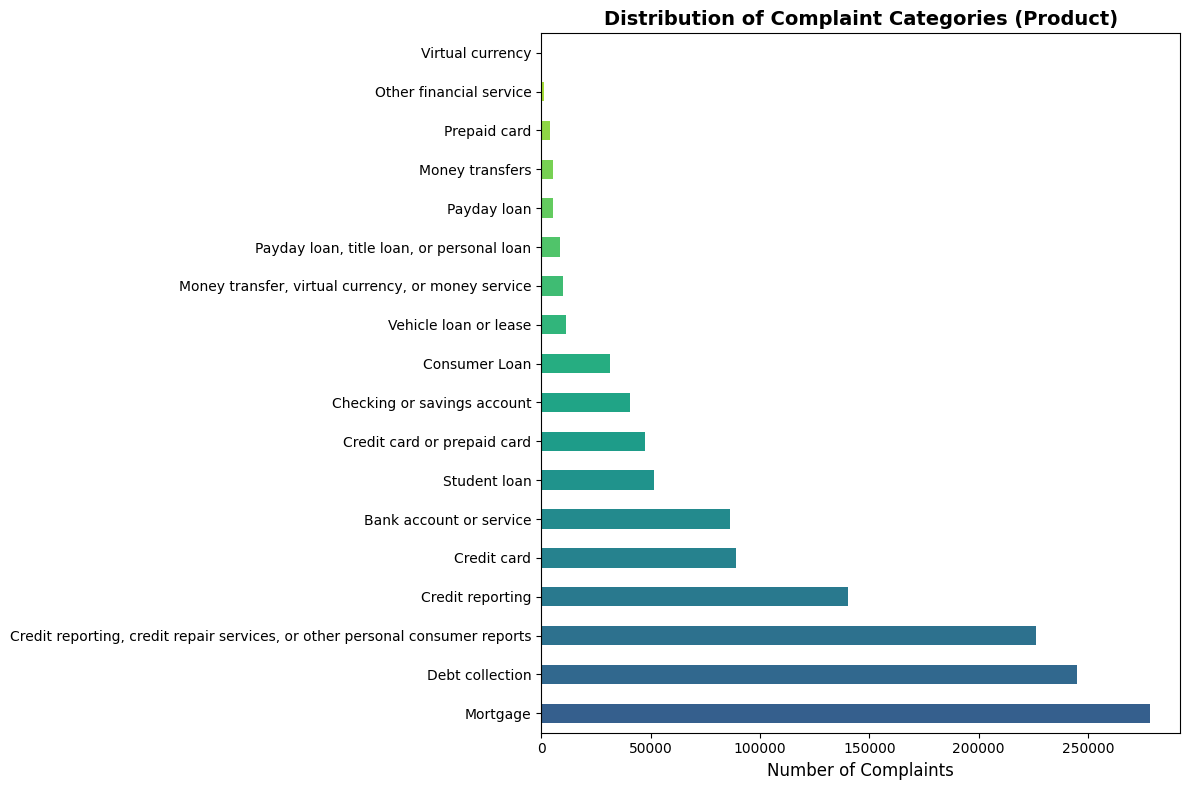

Chart saved to: results/class_distribution.png


In [10]:
# Visualize the distribution as a horizontal bar chart
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(category_counts)))
category_counts.plot(kind='barh', color=colors)
plt.title('Distribution of Complaint Categories (Product)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to: results/class_distribution.png')

---
## CELL 4: Combine Text Features & Apply TF-IDF

**What this does:**
1. Combines `Issue` and `Sub-issue` into one text column — this gives the model more information to work with
2. Applies TF-IDF to convert that text into numbers

**Why combine?** Each column alone has limited info. "managing an account" (Issue) + "problem using a debit or atm card" (Sub-issue) together give a much clearer picture of the complaint than either alone.

**What is TF-IDF?**
- **TF (Term Frequency):** How often a word appears in ONE complaint. If "mortgage" appears 5 times, it's probably important to that complaint.
- **IDF (Inverse Document Frequency):** How rare a word is across ALL complaints. "The" appears everywhere (not useful). "Foreclosure" appears rarely (very useful!).
- **TF × IDF = final score.** Words that are frequent in one complaint but rare overall get the highest scores.

In [11]:
# Step 1: Combine Issue and Sub-issue into one text column
# We use fillna('') to replace any missing Sub-issue values with empty string
# instead of crashing
df['combined_text'] = df['Issue'].fillna('') + ' ' + df['Sub-issue'].fillna('')

# Let's see what the combined text looks like
print('Sample combined text:')
print('-' * 60)
for i in range(3):
    print(f'Row {i}: "{df["combined_text"].iloc[i]}"')
    print()

Sample combined text:
------------------------------------------------------------
Row 0: "managing an account problem using a debit or atm card"

Row 1: "managing an account deposits and withdrawals"

Row 2: "communication tactics frequent or repeated calls"



In [12]:
# Step 2: Apply TF-IDF Vectorization
# max_features=10000 → keep the top 10,000 most important words/phrases
#   (the vocabulary could be 50,000+ words, but most are useless)
# stop_words='english' → remove common English words like "the", "is", "and"
# ngram_range=(1,2) → use single words AND two-word phrases
#   Example: "credit card" as a phrase is more useful than "credit" and "card" separately

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2)
)

# X = features (the TF-IDF numbers), y = target (Product categories)
X = tfidf.fit_transform(df['combined_text'])
y = df['Product']

print(f'TF-IDF Vectorization complete!')
print(f'X shape: {X.shape}')
print(f'  → {X.shape[0]:,} complaints, each represented by {X.shape[1]:,} numerical features')
print(f'\ny shape: {y.shape[0]:,} labels across {y.nunique()} categories')
print(f'\nSample feature names (first 20 words/phrases):')
print(tfidf.get_feature_names_out()[:20].tolist())

TF-IDF Vectorization complete!
X shape: (1282355, 1256)
  → 1,282,355 complaints, each represented by 1,256 numerical features

y shape: 1,282,355 labels across 18 categories

Sample feature names (first 20 words/phrases):
['30', '30 days', '8am', '8am 9pm', '9pm', 'abusive', 'abusive language', 'accessing', 'accessing account', 'account', 'account account', 'account banking', 'account cashing', 'account close', 'account company', 'account confusing', 'account deposits', 'account didn', 'account don', 'account fee']


---
## CELL 5: Train-Test Split (80/20)

**What this does:** Divides the data into two parts:
- **80% Training set** — the model learns patterns from this
- **20% Test set** — we quiz the model on data it has NEVER seen

**Why?** If we test the model on the same data it learned from, it would just memorize the answers (like cheating on an exam by seeing the answer key). Testing on unseen data tells us how it will perform in the real world.

**What is `stratify=y`?** It ensures the 80/20 split preserves the same proportion of each category. If "Mortgage" is 25% of total data, it will be 25% of training AND 25% of test. Without this, random splitting might put 30% in training and 15% in test, which would give unfair results.

**What is `random_state=42`?** It's a seed number that makes the random split reproducible. Every time you run this cell, you get the exact same split. Your teammates should use the same number so everyone's results are comparable.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% for testing
    random_state=42,      # Makes the split reproducible
    stratify=y            # Keeps category proportions equal in both sets
)

print(f'Data split complete!')
print(f'Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'Testing set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/X.shape[0]*100:.0f}%)')
print(f'\nTraining set category distribution (top 5):')
print(y_train.value_counts().head())

Data split complete!
Training set: 1,025,884 samples (80%)
Testing set:  256,471 samples (20%)

Training set category distribution (top 5):
Product
Mortgage                                                                        222478
Debt collection                                                                 195898
Credit reporting, credit repair services, or other personal consumer reports    180782
Credit reporting                                                                112346
Credit card                                                                      71352
Name: count, dtype: int64


---
## CELL 6: Baseline Model (Majority Class Classifier)

**What this does:** Creates the simplest possible "model" — it looks at the training data, finds whichever Product category appears the most, and then predicts THAT category for every single complaint, regardless of what the complaint says.

**Example:** If "Mortgage" is the most common category (say 25% of complaints), the baseline predicts "Mortgage" for ALL 256,000+ test complaints. It will get ~25% accuracy just by guessing the same thing every time.

**Why do we need this?** It's our sanity check. It tells us: "A model that doesn't even read the complaint text can get X% accuracy." If our Naive Bayes can't beat X%, then it's not actually learning anything useful from the text. Every serious ML project starts with a baseline.

In [14]:
# ===== TRAIN THE BASELINE MODEL =====
# strategy='most_frequent' tells it: just predict the most common class every time

baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train, y_train)

# What category does it always predict?
most_common_class = y_train.value_counts().index[0]
most_common_pct = y_train.value_counts(normalize=True).iloc[0] * 100

print(f'Baseline Model Trained!')
print(f'It will ALWAYS predict: "{most_common_class}"')
print(f'This category makes up {most_common_pct:.1f}% of the training data')
print(f'\nSo the expected accuracy is approximately {most_common_pct:.1f}%')

Baseline Model Trained!
It will ALWAYS predict: "Mortgage"
This category makes up 21.7% of the training data

So the expected accuracy is approximately 21.7%


In [15]:
# ===== EVALUATE THE BASELINE MODEL =====
# Predict on test set (it will predict the same class for all 256K+ complaints)
y_pred_baseline = baseline_model.predict(X_test)

# Calculate metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)

print('=' * 60)
print('BASELINE MODEL (Majority Class Classifier) — RESULTS')
print('=' * 60)
print(f'Accuracy:           {baseline_accuracy:.4f}  ({baseline_accuracy*100:.2f}%)')
print(f'Precision (weighted): {baseline_precision:.4f}')
print(f'Recall (weighted):    {baseline_recall:.4f}')
print(f'F1-Score (weighted):  {baseline_f1:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_baseline, zero_division=0))

BASELINE MODEL (Majority Class Classifier) — RESULTS
Accuracy:           0.2169  (21.69%)
Precision (weighted): 0.0470
Recall (weighted):    0.2169
F1-Score (weighted):  0.0773

Detailed Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.00      0.00      0.00     17241
                                                 Checking or savings account       0.00      0.00      0.00      8128
                                                               Consumer Loan       0.00      0.00      0.00      6321
                                                                 Credit card       0.00      0.00      0.00     17838
                                                 Credit card or prepaid card       0.00      0.00      0.00      9530
                                                            Credit reporting     

**How to read the classification report above:**
- Most categories show 0.00 for precision, recall, and F1 — that's expected! The baseline only predicts ONE category, so it completely ignores all other categories.
- The one category it does predict will have some recall but its precision will be low.
- This is exactly why the baseline is bad — it only "knows" one answer.

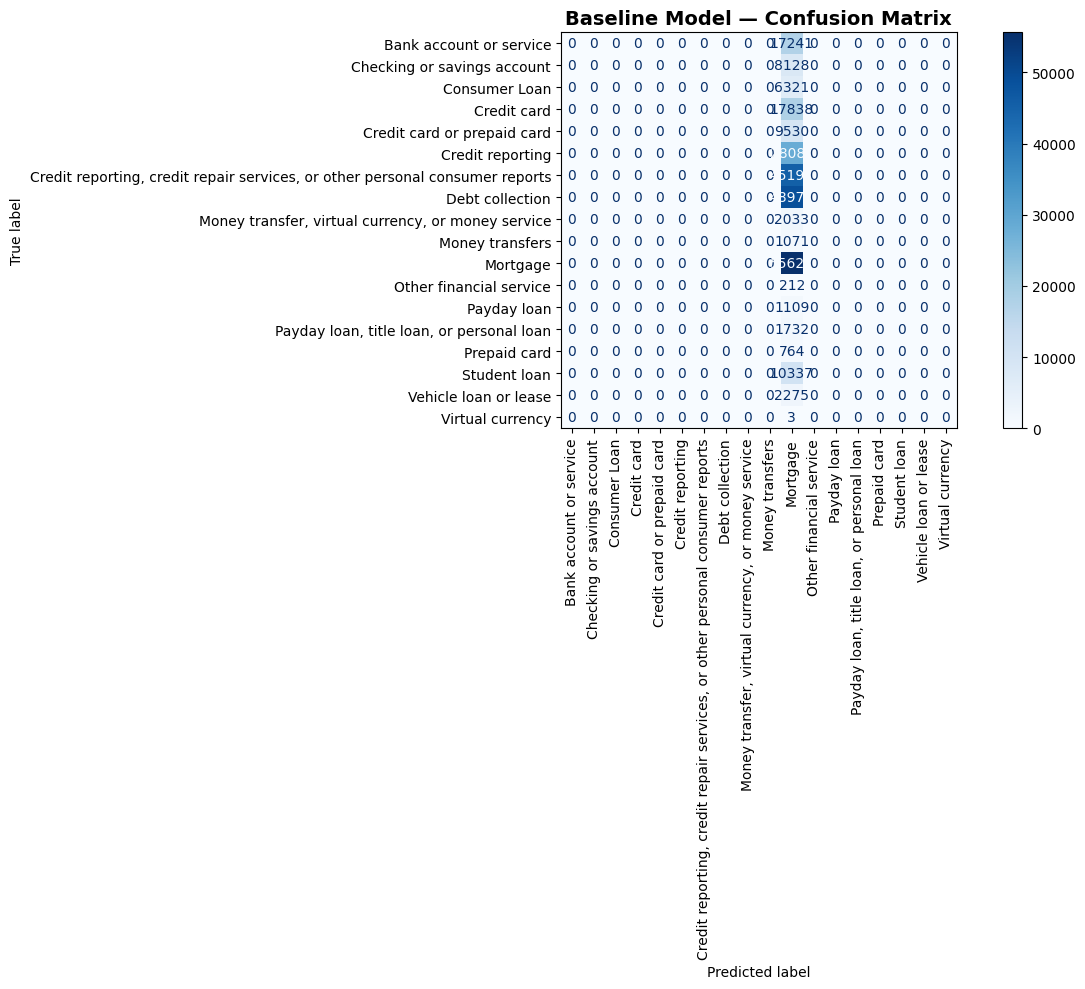

Saved to: results/baseline_confusion_matrix.png


In [16]:
# ===== BASELINE CONFUSION MATRIX =====
# A confusion matrix shows: for each ACTUAL category (rows),
# what did the model PREDICT (columns)?
# Since baseline always predicts one class, you'll see one tall column
# and zeros everywhere else.

fig, ax = plt.subplots(figsize=(14, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    ax=ax,
    cmap='Blues',
    xticks_rotation=90,
    values_format='d'    # Show actual numbers, not scientific notation
)
ax.set_title('Baseline Model — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to: results/baseline_confusion_matrix.png')

---
## CELL 7: Naive Bayes Model (Default Settings)

**What is Naive Bayes?**
It uses probability (Bayes' Theorem) to classify. During training, it learns:
- "In Mortgage complaints, the word 'loan' appears 80% of the time"
- "In Credit Card complaints, the word 'charge' appears 70% of the time"

When it sees a new complaint, it calculates: "Given all these words, what's the probability this is Mortgage? Credit Card? Debt Collection?" and picks the highest one.

**Why 'Naive'?** It assumes every word is independent — it doesn't care about word order or phrases. "Credit card fraud" and "fraud card credit" are the same to it. This is a simplification, but it works surprisingly well for text.

**Why MultinomialNB?** There are different types of Naive Bayes. Multinomial is specifically designed for text data where features are word counts or TF-IDF scores.

**What is alpha=1.0?** This is "Laplace smoothing." Without it, if the word "foreclosure" never appeared in Credit Card complaints during training, the probability becomes 0, and 0 multiplied by anything is 0 — the entire prediction breaks. Alpha adds a tiny count to every word so no probability is ever exactly zero. We start with the default (1.0) and tune it later.

In [17]:
# ===== TRAIN NAIVE BAYES WITH DEFAULT SETTINGS =====
nb_default = MultinomialNB(alpha=1.0)
nb_default.fit(X_train, y_train)

# Predict on test set
y_pred_nb_default = nb_default.predict(X_test)

# Calculate metrics
nb_default_accuracy = accuracy_score(y_test, y_pred_nb_default)
nb_default_f1 = f1_score(y_test, y_pred_nb_default, average='weighted')

print('=' * 60)
print('NAIVE BAYES (Default alpha=1.0) — RESULTS')
print('=' * 60)
print(f'Accuracy:           {nb_default_accuracy:.4f}  ({nb_default_accuracy*100:.2f}%)')
print(f'F1-Score (weighted):  {nb_default_f1:.4f}')
print(f'\nImprovement over baseline: +{(nb_default_accuracy - baseline_accuracy)*100:.2f}% accuracy')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_nb_default))

NAIVE BAYES (Default alpha=1.0) — RESULTS
Accuracy:           0.9675  (96.75%)
F1-Score (weighted):  0.9667

Improvement over baseline: +75.07% accuracy

Detailed Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       1.00      1.00      1.00     17241
                                                 Checking or savings account       0.92      0.99      0.95      8128
                                                               Consumer Loan       0.95      0.97      0.96      6321
                                                                 Credit card       1.00      0.87      0.93     17838
                                                 Credit card or prepaid card       0.96      0.87      0.91      9530
                                                            Credit reporting       0.96      1.00      0.

---
## CELL 8: Hyperparameter Tuning (Finding the Best Alpha)

**What this does:** Instead of guessing which alpha value is best, we systematically try many different values and let the computer find the winner.

**How GridSearchCV works:**
1. We give it a list of alpha values to try: [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
2. For EACH alpha value, it does 5-fold cross-validation:
   - Splits the training data into 5 equal parts
   - Trains on 4 parts, tests on the 5th
   - Repeats 5 times (each part gets a turn as the test)
   - Averages the 5 scores
3. Returns the alpha that gave the highest average F1-score

**Why F1-score and not accuracy?** Because our data is imbalanced. A model could get 25% accuracy by only predicting one category (that's what our baseline does!). F1-score balances precision and recall, so it rewards models that do well across ALL categories, not just the big ones.

**Note:** This cell might take a few minutes to run because it's training 8 alphas × 5 folds = 40 models total.

In [18]:
# ===== GRID SEARCH FOR BEST ALPHA =====
print('Starting hyperparameter tuning...')
print('Testing 8 alpha values with 5-fold cross-validation (= 40 model trainings)')
print('This may take a few minutes...\n')

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_search = GridSearchCV(
    MultinomialNB(),        # The model to tune
    param_grid,             # The values to try
    cv=5,                   # 5-fold cross-validation
    scoring='f1_weighted',  # Optimize for weighted F1-score
    n_jobs=-1,              # Use all CPU cores (faster!)
    verbose=1               # Show progress
)

grid_search.fit(X_train, y_train)

print(f'\nTuning complete!')
print(f'Best alpha found: {grid_search.best_params_["alpha"]}')
print(f'Best cross-validation F1-score: {grid_search.best_score_:.4f}')

Starting hyperparameter tuning...
Testing 8 alpha values with 5-fold cross-validation (= 40 model trainings)
This may take a few minutes...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning complete!
Best alpha found: 0.001
Best cross-validation F1-score: 0.9682


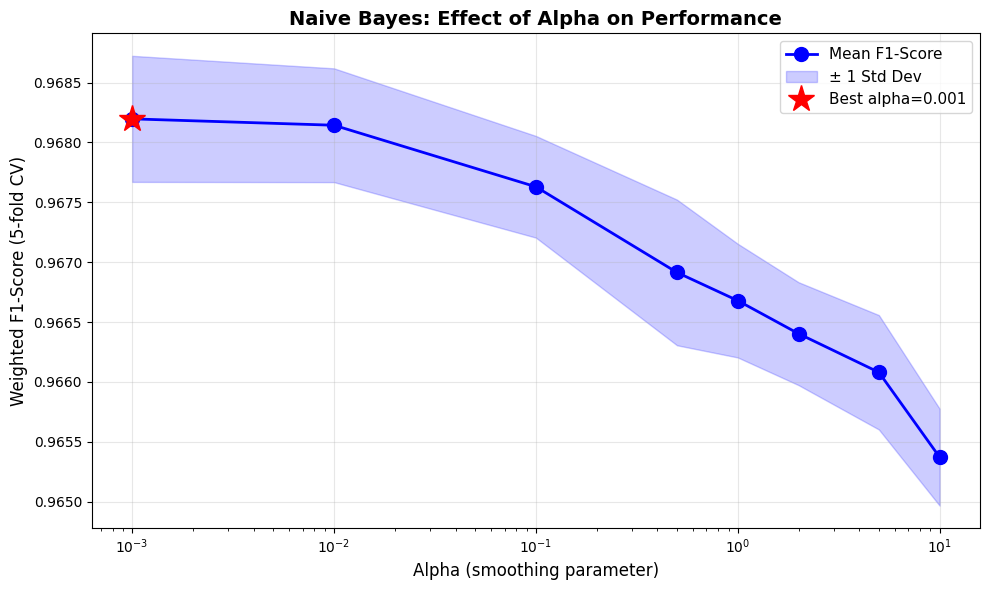

Saved to: results/alpha_tuning.png


In [19]:
# ===== VISUALIZE: HOW ALPHA AFFECTS PERFORMANCE =====
# This chart shows you the "sweet spot" for alpha
# Too small alpha = overfitting (memorizes training data, fails on test)
# Too large alpha = underfitting (over-smooths, loses important patterns)

results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(
    param_grid['alpha'],
    results['mean_test_score'],
    'bo-', linewidth=2, markersize=10, label='Mean F1-Score'
)
# Shaded area shows the standard deviation (uncertainty)
plt.fill_between(
    param_grid['alpha'],
    results['mean_test_score'] - results['std_test_score'],
    results['mean_test_score'] + results['std_test_score'],
    alpha=0.2, color='blue', label='± 1 Std Dev'
)

# Mark the best alpha with a red star
best_idx = results['mean_test_score'].idxmax()
plt.plot(
    results['param_alpha'].iloc[best_idx],
    results['mean_test_score'].iloc[best_idx],
    'r*', markersize=20, label=f'Best alpha={grid_search.best_params_["alpha"]}'
)

plt.xscale('log')  # Log scale because alpha values span 0.001 to 10
plt.xlabel('Alpha (smoothing parameter)', fontsize=12)
plt.ylabel('Weighted F1-Score (5-fold CV)', fontsize=12)
plt.title('Naive Bayes: Effect of Alpha on Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/alpha_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to: results/alpha_tuning.png')

---
## CELL 9: Best Naive Bayes — Final Evaluation

**What this does:** Takes the best alpha from tuning and evaluates it on the test set.

**Why separate from tuning?** GridSearchCV used the TRAINING data (with cross-validation) to find the best alpha. Now we test on the TEST set — data the model has truly never seen — to get an honest, unbiased performance score. This is the number you report in your project.

In [20]:
# ===== EVALUATE THE BEST NAIVE BAYES MODEL =====
# grid_search.best_estimator_ automatically gives us the model with the best alpha
best_nb = grid_search.best_estimator_
y_pred_best_nb = best_nb.predict(X_test)

# Calculate all metrics
best_nb_accuracy = accuracy_score(y_test, y_pred_best_nb)
best_nb_precision = precision_score(y_test, y_pred_best_nb, average='weighted')
best_nb_recall = recall_score(y_test, y_pred_best_nb, average='weighted')
best_nb_f1 = f1_score(y_test, y_pred_best_nb, average='weighted')

print('=' * 60)
print(f'BEST NAIVE BAYES (alpha={grid_search.best_params_["alpha"]}) — FINAL RESULTS')
print('=' * 60)
print(f'Accuracy:             {best_nb_accuracy:.4f}  ({best_nb_accuracy*100:.2f}%)')
print(f'Precision (weighted): {best_nb_precision:.4f}')
print(f'Recall (weighted):    {best_nb_recall:.4f}')
print(f'F1-Score (weighted):  {best_nb_f1:.4f}')
print()
print(f'Improvement over baseline: +{(best_nb_accuracy - baseline_accuracy)*100:.2f}% accuracy')
print(f'Improvement over default NB: +{(best_nb_accuracy - nb_default_accuracy)*100:.2f}% accuracy')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_best_nb))

BEST NAIVE BAYES (alpha=0.001) — FINAL RESULTS
Accuracy:             0.9686  (96.86%)
Precision (weighted): 0.9704
Recall (weighted):    0.9686
F1-Score (weighted):  0.9679

Improvement over baseline: +75.17% accuracy
Improvement over default NB: +0.10% accuracy

Detailed Classification Report:
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       1.00      1.00      1.00     17241
                                                 Checking or savings account       0.92      0.99      0.95      8128
                                                               Consumer Loan       0.95      0.97      0.96      6321
                                                                 Credit card       1.00      0.87      0.93     17838
                                                 Credit card or prepaid card       0.98      0.87      0.92      

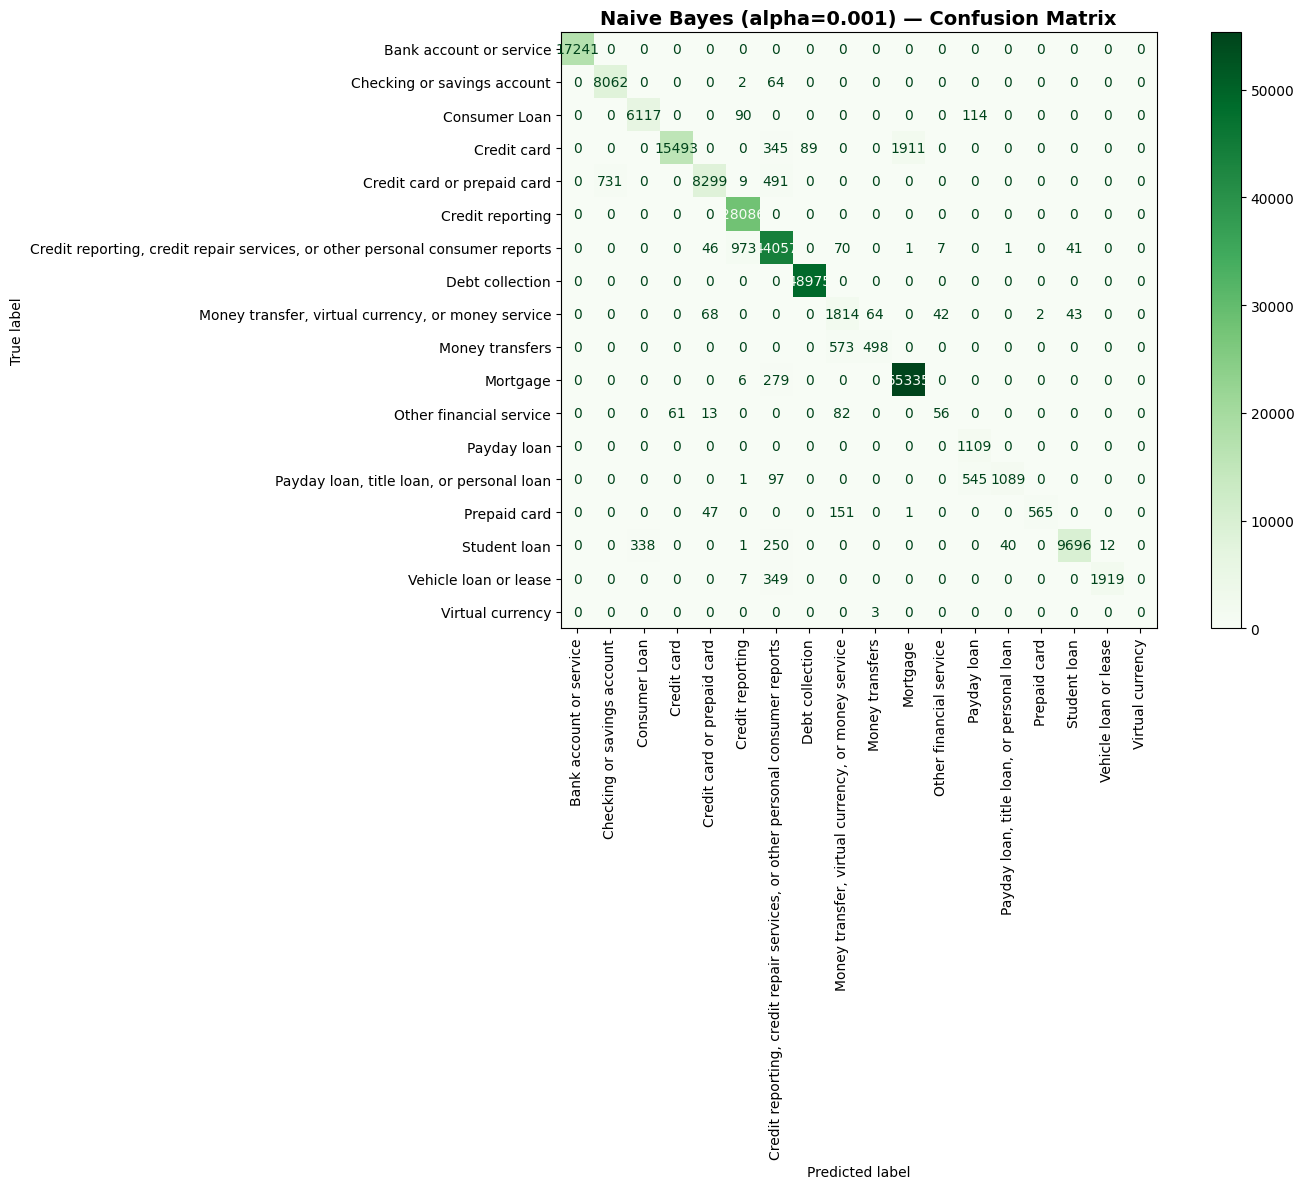

Saved to: results/naive_bayes_confusion_matrix.png


In [21]:
# ===== CONFUSION MATRIX FOR BEST NAIVE BAYES =====
# This heatmap shows WHERE the model gets confused
# Darker squares on the diagonal = correct predictions (good!)
# Darker squares OFF the diagonal = misclassifications (the model confused two categories)

fig, ax = plt.subplots(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_nb,
    ax=ax,
    cmap='Greens',
    xticks_rotation=90,
    values_format='d'
)
ax.set_title(
    f'Naive Bayes (alpha={grid_search.best_params_["alpha"]}) — Confusion Matrix',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../results/naive_bayes_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to: results/naive_bayes_confusion_matrix.png')

---
## CELL 10: Side-by-Side Comparison — Baseline vs Naive Bayes

**What this does:** Creates a clear comparison table and bar chart showing that Naive Bayes actually learned something useful from the text, unlike the baseline which just guesses blindly.

**This is the key result for your report** — it proves that machine learning adds real value.

In [22]:
# ===== COMPARISON TABLE =====
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline (Majority Class)',
        f'Naive Bayes (alpha={grid_search.best_params_["alpha"]})'
    ],
    'Accuracy': [baseline_accuracy, best_nb_accuracy],
    'Precision': [baseline_precision, best_nb_precision],
    'Recall': [baseline_recall, best_nb_recall],
    'F1-Score': [baseline_f1, best_nb_f1]
})

print('=' * 70)
print('FINAL MODEL COMPARISON')
print('=' * 70)
print(comparison_df.to_string(index=False))
print(f'\nNaive Bayes beats baseline by +{(best_nb_accuracy - baseline_accuracy)*100:.2f}% accuracy')

FINAL MODEL COMPARISON
                    Model  Accuracy  Precision   Recall  F1-Score
Baseline (Majority Class)  0.216867   0.047031 0.216867  0.077299
Naive Bayes (alpha=0.001)  0.968573   0.970422 0.968573  0.967942

Naive Bayes beats baseline by +75.17% accuracy


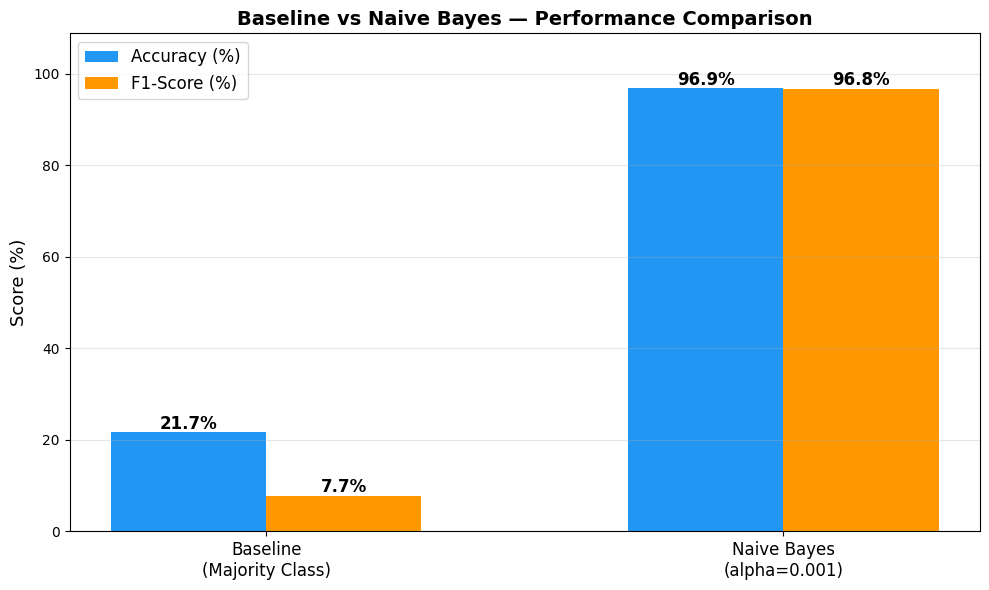

Saved to: results/model_comparison.png


In [23]:
# ===== COMPARISON BAR CHART =====
models = ['Baseline\n(Majority Class)', f'Naive Bayes\n(alpha={grid_search.best_params_["alpha"]})']
metrics = {
    'Accuracy': [baseline_accuracy * 100, best_nb_accuracy * 100],
    'F1-Score': [baseline_f1 * 100, best_nb_f1 * 100]
}

x = np.arange(len(models))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, metrics['Accuracy'], width, label='Accuracy (%)', color='#2196F3')
bars2 = ax.bar(x + width/2, metrics['F1-Score'], width, label='F1-Score (%)', color='#FF9800')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Baseline vs Naive Bayes — Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, max(max(metrics['Accuracy']), max(metrics['F1-Score'])) + 12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to: results/model_comparison.png')

---
## CELL 11: Top Predictive Words per Category

**What this does:** Shows which words Naive Bayes considers most important for each Product category.

**Why this is useful:** It helps us understand what the model actually learned. If the top words for "Mortgage" are things like "loan", "payment", "escrow", "foreclosure" — that makes sense! But if the top words are random or unrelated, something might be wrong with our data or model.

**Good for your report:** This is an easy way to explain to your professor that the model is learning meaningful patterns, not just memorizing.

In [24]:
# ===== TOP 10 PREDICTIVE WORDS PER CATEGORY =====
feature_names = tfidf.get_feature_names_out()
classes = best_nb.classes_

print('Top 10 Most Predictive Words/Phrases per Category')
print('=' * 70)

for i, category in enumerate(classes):
    # feature_log_prob_ contains the log-probability of each word for each category
    # Higher log-prob = more likely to appear in that category
    top_indices = np.argsort(best_nb.feature_log_prob_[i])[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f'\n📌 {category}:')
    print(f'   {", ".join(top_words)}')

Top 10 Most Predictive Words/Phrases per Category

📌 Bank account or service:
   management, account opening, closing management, opening closing, opening, closing, deposits withdrawals, deposits, withdrawals, account

📌 Checking or savings account:
   managing account, managing, account, account deposits, withdrawals, deposits, deposits withdrawals, problem, account problem, funds

📌 Consumer Loan:
   lease, loan lease, managing loan, managing, loan, unable pay, problems unable, unable, problems, pay

📌 Credit card:
   billing, disputes, billing disputes, fee, embezzlement, fraud embezzlement, theft fraud, cancelling account, closing cancelling, cancelling

📌 Credit card or prepaid card:
   card, purchase, problem, fees, statement, credit card, problem purchase, purchase shown, shown statement, shown

📌 Credit reporting:
   information, credit report, information credit, credit, report, incorrect information, incorrect, report account, status, account status

📌 Credit reporting, credi

---
## CELL 12: Save All Results for Team Report

**What this does:** Saves your metrics to a CSV file so your teammates (Dev and Sristi) can easily combine their model results with yours for the final comparison.

**The file will be at:** `results/kunal_model_results.csv`

In [25]:
# ===== CREATE RESULTS FOLDER AND SAVE =====
import os
os.makedirs('../results', exist_ok=True)

# Save metrics to CSV
results_df = pd.DataFrame({
    'Model': [
        'Baseline (Majority Class)',
        'Naive Bayes (default alpha=1.0)',
        f'Naive Bayes (tuned alpha={grid_search.best_params_["alpha"]})'
    ],
    'Accuracy': [baseline_accuracy, nb_default_accuracy, best_nb_accuracy],
    'Precision (Weighted)': [
        baseline_precision,
        precision_score(y_test, y_pred_nb_default, average='weighted'),
        best_nb_precision
    ],
    'Recall (Weighted)': [
        baseline_recall,
        recall_score(y_test, y_pred_nb_default, average='weighted'),
        best_nb_recall
    ],
    'F1-Score (Weighted)': [
        baseline_f1,
        f1_score(y_test, y_pred_nb_default, average='weighted'),
        best_nb_f1
    ]
})

results_df.to_csv('../results/kunal_model_results.csv', index=False)

print('Results saved to: results/kunal_model_results.csv')
print()
print(results_df.to_string(index=False))

Results saved to: results/kunal_model_results.csv

                          Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
      Baseline (Majority Class)  0.216867              0.047031           0.216867             0.077299
Naive Bayes (default alpha=1.0)  0.967548              0.969210           0.967548             0.966666
Naive Bayes (tuned alpha=0.001)  0.968573              0.970422           0.968573             0.967942


---
## Summary

### What we did:
1. **Loaded** the preprocessed CFPB consumer complaints dataset (1.28M records, 18 categories)
2. **Combined** Issue + Sub-issue text and converted to numbers using TF-IDF (10,000 features)
3. **Split** data 80/20 with stratification for fair evaluation
4. **Built Baseline Model** — always predicts the most common category (our minimum bar)
5. **Built Naive Bayes** — learned word patterns to classify complaints
6. **Tuned alpha** using GridSearchCV with 5-fold cross-validation
7. **Compared** all models with Accuracy, Precision, Recall, and F1-Score

### Key Findings:
- Baseline sets the minimum accuracy bar that any real model must beat
- Naive Bayes significantly outperforms the baseline by learning word-category patterns
- Tuning alpha provides further improvement
- The confusion matrix reveals which product categories are hardest to distinguish
- Top predictive words confirm the model learned meaningful patterns

### Files saved in `results/` folder:
- `class_distribution.png` — bar chart of category distribution
- `baseline_confusion_matrix.png` — confusion matrix for baseline
- `alpha_tuning.png` — alpha vs performance chart
- `naive_bayes_confusion_matrix.png` — confusion matrix for best NB
- `model_comparison.png` — side-by-side comparison chart
- `kunal_model_results.csv` — all metrics in a table